# India Scholarly Migration: Deep-Dive Exploratory Analysis

**Author:** Ujjwal Kumar Swain
**Affiliation:** United Nations Population Fund (UNFPA) India, Odisha State Office
**Academic background:** M.Sc. Geoinformation Science, University of Twente and IIRS-ISRO

---

### Data source

> Akbaritabar A., Theile T. and Zagheni E. (2024). Bilateral flows and rates of international
> migration of scholars for 210 countries, 1998-2020. *Scientific Data* 11, 816.
> doi: 10.1038/s41597-024-03655-9
> Data: doi: 10.5281/zenodo.11145735 (CC-BY 4.0)

### Prerequisite

Run `scholarly_migration_replication.ipynb` first. That notebook downloads and extracts the
raw data and exports processed Parquet files to `data/processed/`. This notebook loads those
Parquet files by default, falling back to the raw CSVs if the Parquet files are not found.

### Purpose

This notebook zooms in on India specifically. The replication notebook established that
India has one of the most persistently negative Net Migration Rates among all 210 countries
in the dataset. The questions explored here are:

- How has India's global ranking as a net sender of scholars changed year by year?
- How does India compare to other large emerging economies (BRICS)?
- Which specific bilateral corridors drive the net loss, and how asymmetric are they?
- Is inequality in scholar migration rates within Asia increasing or decreasing over time?
- Has the destination mix for Indian scholars shifted across different periods?
- Is there any evidence of increasing return migration or circulation on the India-USA corridor?
- Does India function as a regional hub within South Asia?

### Scope and epistemics

All findings are **descriptive**. This notebook measures patterns in affiliation change data.
It does not identify causes, and it does not distinguish between voluntary mobility and
involuntary displacement. Affiliation change is a proxy for physical relocation; a researcher
who keeps a home institution affiliation while working abroad would not be counted as migrating.


# **Section 1: Environment Setup**

I keep the setup cell in the India notebook as well, even though the replication notebook
runs the same setup, because this notebook is sometimes run independently in a fresh session.
The two notebooks share the same colour palette and visual style so that figures from both
can be placed side by side without visual inconsistency.

The `CITATION` constant is a short data attribution string that I embed in every figure
title. This is good practice for any figure that might be extracted from the notebook and
used in a presentation or report.

In [13]:
!pip install plotly kaleido -q

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

Path('figures/india').mkdir(parents=True, exist_ok=True)

# MPIDR house colour palette (same as replication notebook)
TEAL   = '#006E6E'
ORANGE = '#E07B39'
BLUE   = '#1A6FAF'
RED    = '#C0392B'
GRAY   = '#95A5A6'
GREEN  = '#27AE60'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Short attribution string embedded in all figure titles
CITATION = 'Data: Akbaritabar, Theile and Zagheni (2024) Scientific Data'

print('Setup complete.')


Setup complete.


# **Section 2: Load Data**

The data loading function uses a three-tier fallback strategy:

1. **Parquet files in `data/processed/`**: The fastest path. These are created by running
   `scholarly_migration_replication.ipynb` first. Parquet preserves column types and loads
   in under a second for this dataset size.

2. **Raw CSVs in `data/raw/extracted/`**: If the Parquet files do not exist (e.g. the two
   notebooks are run in separate Colab sessions), I look for the original extracted CSVs.
   I match by exact filename rather than keyword patterns at this stage, because I already
   know the exact names from the replication notebook.

3. **Download from Zenodo**: If neither the Parquet files nor the extracted CSVs exist, I
   download the full archive from Zenodo. This adds several minutes but requires no manual
   steps from the user.

After loading, I apply three transformations that apply for the entire notebook:
- Filter to 1998-2020 to match the paper's study window
- Cast `year` to integer (it arrives as float64 in some versions of the CSV)
- Pre-extract the India subset so it is available without filtering in every cell

In [14]:
!pip install pyarrow -q

import zipfile
import requests
from pathlib import Path
from tqdm import tqdm


def load_data():
    parquet_sc = Path('data/processed/scopus_country.parquet')
    parquet_fl = Path('data/processed/scopus_flows.parquet')

    if parquet_sc.exists() and parquet_fl.exists():
        print('Loading from Parquet files (fast path)...')
        sc = pd.read_parquet(parquet_sc)
        fl = pd.read_parquet(parquet_fl)
        return sc, fl

    print('Parquet files not found. Checking for extracted CSVs...')
    extract_dir = Path('data/raw/extracted')

    if not extract_dir.exists() or not any(extract_dir.rglob('*.csv')):
        print('Extracted CSVs not found. Downloading from Zenodo...')
        Path('data/raw').mkdir(parents=True, exist_ok=True)
        RECORD_ID = '11145735'
        meta = requests.get(f'https://zenodo.org/api/records/{RECORD_ID}').json()
        all_files = {f['key']: f['links']['self'] for f in meta.get('files', [])}
        zip_fname = [k for k in all_files if k.endswith('.zip')][0]
        zip_local = Path(f'data/raw/{zip_fname}')
        if not zip_local.exists():
            r = requests.get(all_files[zip_fname], stream=True)
            total = int(r.headers.get('content-length', 0))
            with open(zip_local, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as pbar:
                for chunk in r.iter_content(65536):
                    f.write(chunk)
                    pbar.update(len(chunk))
        extract_dir.mkdir(exist_ok=True)
        with zipfile.ZipFile(zip_local, 'r') as zf:
            zf.extractall(extract_dir)
        print('Downloaded and extracted.')

    # Find the two target files by exact filename
    all_csvs = list(extract_dir.rglob('*.csv'))

    def find_exact(csvs, name):
        for p in csvs:
            if p.name == name:
                return p
        return None

    sc_path = find_exact(all_csvs, 'scopus_2024_V1_scholarlymigration_country.csv')
    fl_path = find_exact(all_csvs, 'scopus_2024_V1_scholarlymigration_countryflows.csv')

    if sc_path is None or fl_path is None:
        raise FileNotFoundError(
            'Could not locate target CSV files. '
            'Available: ' + str([c.name for c in all_csvs])
        )

    print(f'Country file : {sc_path}')
    print(f'Flow file    : {fl_path}')

    sc = pd.read_csv(sc_path)
    fl = pd.read_csv(fl_path)
    return sc, fl


sc, fl = load_data()

# Filter to study window and standardise year type
sc = sc[sc['year'] <= 2020].copy()
fl = fl[fl['year'] <= 2020].copy()
sc['year'] = sc['year'].astype(int)
fl['year'] = fl['year'].astype(int)

# Pre-extract the India subset  -  used in almost every section
india_sc = sc[sc['countrycode'] == 'IND'].sort_values('year').copy()

print(f'Country data : {sc.shape} | {sc["year"].min()}-{sc["year"].max()}')
print(f'Flow data    : {fl.shape} | {fl["year"].min()}-{fl["year"].max()}')
print(f'India rows   : {len(india_sc)} (one per year, 1996-2020)')
print(f'Columns (sc) : {sc.columns.tolist()}')
print(f'Columns (fl) : {fl.columns.tolist()}')


Parquet files not found. Checking for extracted CSVs...
Country file : data/raw/extracted/Global-flows-and-rates-of-international-migration-of-scholars-2024_v1.1/data_input/scopus_2024_V1_scholarlymigration_country.csv
Flow file    : data/raw/extracted/Global-flows-and-rates-of-international-migration-of-scholars-2024_v1.1/data_input/scopus_2024_V1_scholarlymigration_countryflows.csv
Country data : (5147, 10) | 1996-2020
Flow data    : (122040, 6) | 1994-2020
India rows   : 25 (one per year, 1996-2020)
Columns (sc) : ['year', 'countrycode', 'padded_population_of_researchers', 'paddedpop', 'number_of_inmigrations', 'number_of_outmigrations', 'netmigration', 'outmigrationrate', 'inmigrationrate', 'netmigrationrate']
Columns (fl) : ['migrationfrom', 'migrationto', 'year', 'n_migrations', 'n_migrations_back', 'netmigrations']


### **Section 3: India's Annual Ranking Among Global Net Senders**

The replication notebook computed India's average rank across the whole study period.
An average can hide important dynamics: a country might have been the worst sender in
1998 and dramatically improved by 2020, or the reverse.

I compute India's rank for each individual year by sorting all countries from lowest
NMR to highest and recording India's position. Rank 1 means India was the strongest
net sender in that year. Rank 210 would mean India was the strongest net receiver.

**Two panels, two perspectives:**
- The rank panel shows India's competitive position relative to other countries. A
  rank that stays low (strong sender) even as the NMR improves means other countries
  have improved faster.
- The NMR panel shows the absolute rate, which is more meaningful for understanding
  the scale of the phenomenon.

Together they reveal whether India's brain drain is improving in absolute terms,
in relative terms, or in neither.


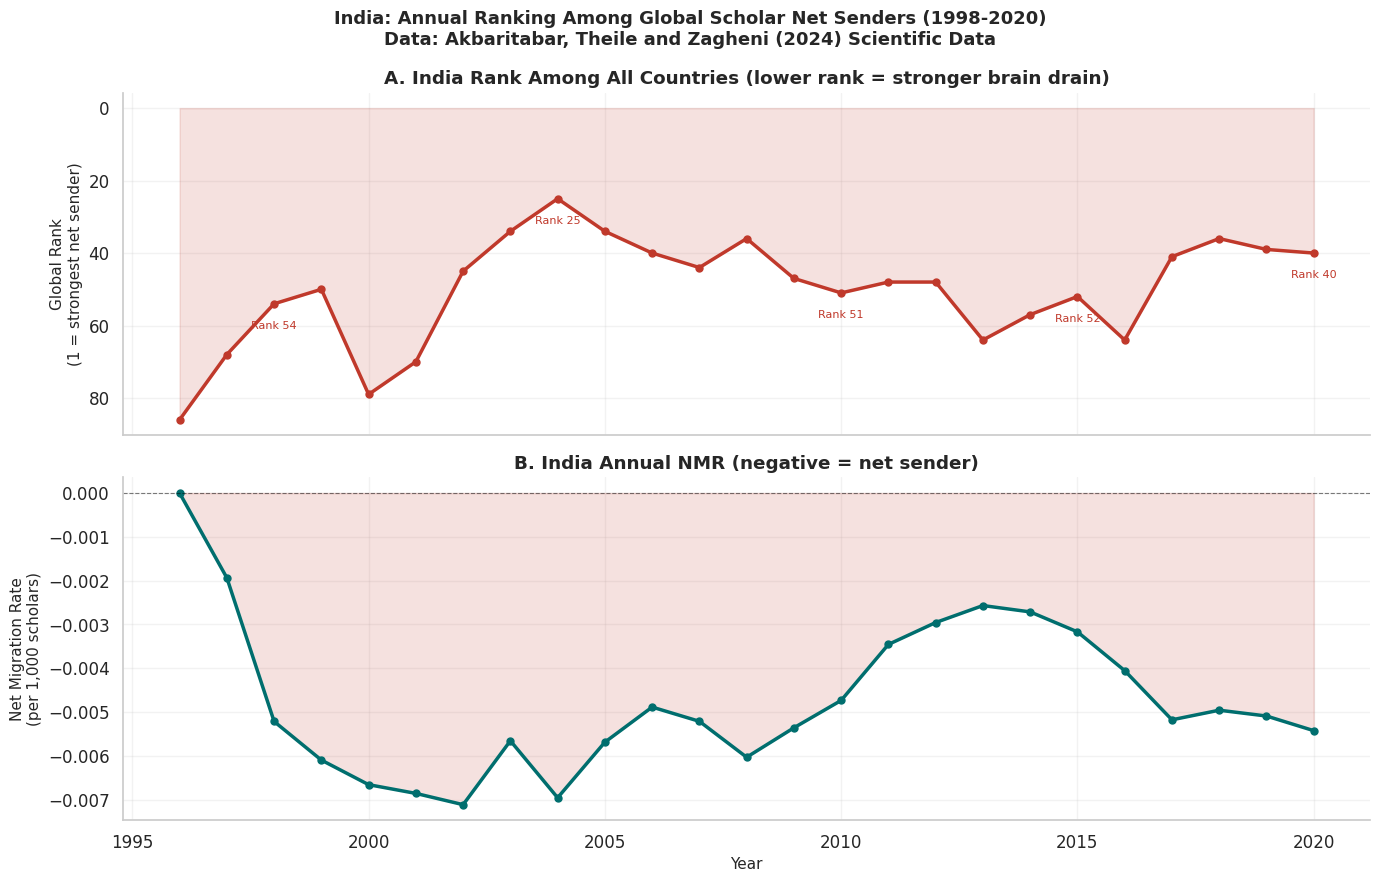

India ranking summary (selected years):
 year  rank  total     nmr
 1996    86    202  0.0000
 1997    68    205 -0.0019
 1998    54    191 -0.0052
 1999    50    188 -0.0061
 2000    79    193 -0.0067
 2001    70    199 -0.0069
 2002    45    197 -0.0071
 2003    34    198 -0.0057
 2004    25    199 -0.0070
 2005    34    201 -0.0057
 2006    40    205 -0.0049
 2007    44    206 -0.0052
 2008    36    205 -0.0060
 2009    47    210 -0.0054
 2010    51    207 -0.0047
 2011    48    201 -0.0035
 2012    48    215 -0.0030
 2013    64    214 -0.0026
 2014    57    215 -0.0027
 2015    52    217 -0.0032
 2016    64    217 -0.0041
 2017    41    216 -0.0052
 2018    36    214 -0.0050
 2019    39    213 -0.0051
 2020    40    219 -0.0054


In [15]:
# Compute India's rank among all countries, separately for each year
# Rank 1 = strongest net sender (lowest NMR) in that year
yearly_ranks = []
for yr in sorted(sc['year'].unique()):
    yr_df = sc[sc['year'] == yr][['countrycode', 'netmigrationrate']].dropna()
    yr_df = yr_df.sort_values('netmigrationrate').reset_index(drop=True)
    yr_df['rank'] = range(1, len(yr_df) + 1)
    yr_df['total'] = len(yr_df)
    yr_df['year'] = yr
    india_row = yr_df[yr_df['countrycode'] == 'IND']
    if not india_row.empty:
        yearly_ranks.append({
            'year'           : yr,
            'rank'           : india_row['rank'].values[0],
            'total'          : india_row['total'].values[0],
            'nmr'            : india_row['netmigrationrate'].values[0],
            'pct_from_bottom': india_row['rank'].values[0] / india_row['total'].values[0] * 100,
        })

rank_df = pd.DataFrame(yearly_ranks)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle(
    f'India: Annual Ranking Among Global Scholar Net Senders (1998-2020)\n{CITATION}',
    fontweight='bold', fontsize=13
)

# Panel A: rank over time (inverted axis: rank 1 is at the top, meaning worst sender)
axes[0].plot(rank_df['year'], rank_df['rank'], color=RED, lw=2.5, marker='o', ms=5)
axes[0].fill_between(rank_df['year'], rank_df['rank'], alpha=0.15, color=RED)
axes[0].set_ylabel('Global Rank\n(1 = strongest net sender)', fontsize=11)
axes[0].set_title('A. India Rank Among All Countries (lower rank = stronger brain drain)',
                  fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.25)
for _, row in rank_df.iterrows():
    if row['year'] in [1998, 2004, 2010, 2015, 2020]:
        axes[0].annotate(
            f'Rank {int(row["rank"])}',
            (row['year'], row['rank']),
            textcoords='offset points', xytext=(0, -18),
            fontsize=8, ha='center', color=RED
        )

# Panel B: NMR over time
axes[1].plot(rank_df['year'], rank_df['nmr'], color=TEAL, lw=2.5, marker='o', ms=5)
axes[1].fill_between(rank_df['year'], rank_df['nmr'], 0, alpha=0.15, color=RED)
axes[1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
axes[1].set_ylabel('Net Migration Rate\n(per 1,000 scholars)', fontsize=11)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_title('B. India Annual NMR (negative = net sender)', fontweight='bold')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig('figures/india/fig1_india_ranking.png', dpi=180, bbox_inches='tight')
plt.show()

print('India ranking summary (selected years):')
print(rank_df[['year', 'rank', 'total', 'nmr']].to_string(index=False))


# **Section 4: India vs BRICS: Comparative NMR Trajectories**

Comparing India's scholar migration rate to other large emerging economies provides
important context. If every large emerging economy has a similarly negative NMR, then
India's situation reflects a structural feature of the global academic system rather
than something specific to India. If India is an outlier even within this group,
that calls for a more India-specific explanation.

I use the BRICS grouping (Brazil, Russia, India, China, South Africa) because it is
a widely used comparison set of large non-OECD economies at roughly comparable stages
of research system development in the 1990s.

**Design choice:** India's line is drawn thicker (lw=3.5) and its markers are larger
to make it visually primary. All other countries are secondary context. Direct labels
at the rightmost data point replace the legend.

**Why mark 2008?**
The global financial crisis had asymmetric effects: it reduced hiring in Western
universities (affecting where Indian scholars could go) while simultaneously India
increased domestic research investment under the 11th Five Year Plan. Whether this
produced any measurable change in NMR is an empirical question the chart can answer.

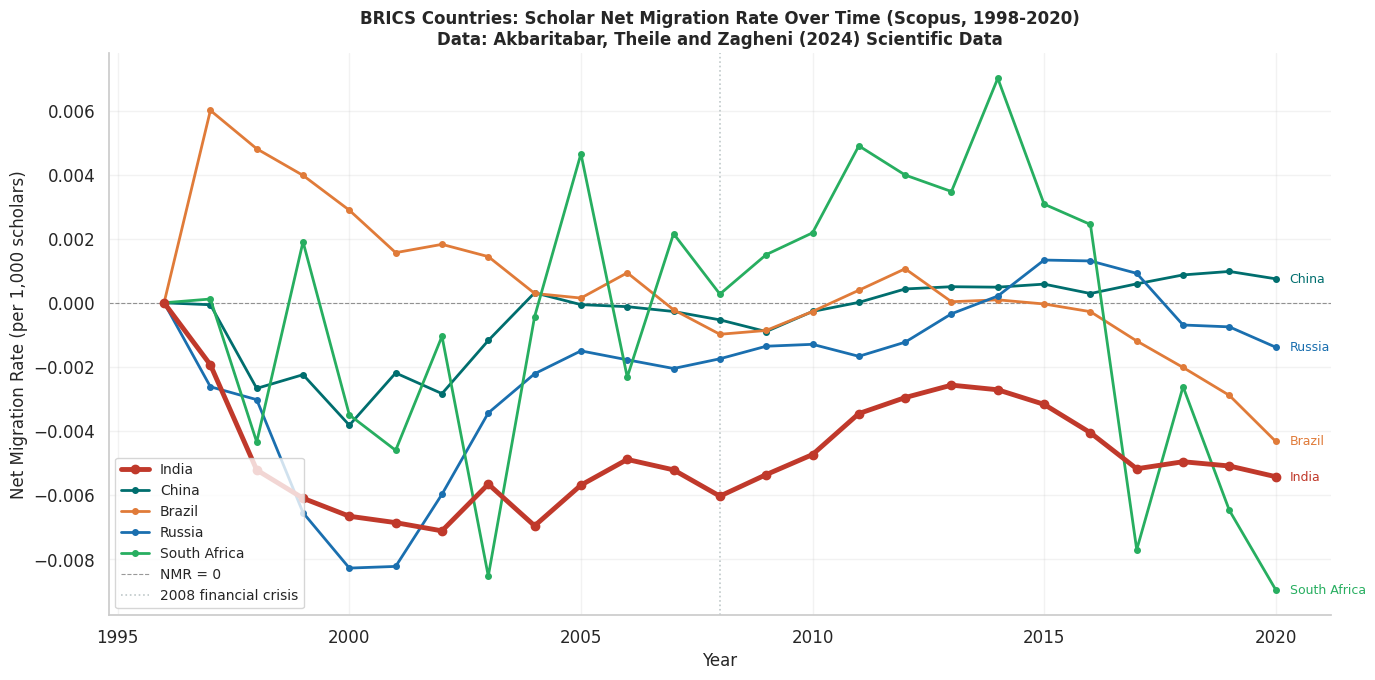


BRICS average NMR 1998-2020:
  India: -0.0047
  China: -0.0005
  Brazil: 0.0005
  Russia: -0.0021
  South Africa: -0.0005


In [16]:
BRICS = {'IND': 'India', 'CHN': 'China', 'BRA': 'Brazil', 'RUS': 'Russia', 'ZAF': 'South Africa'}
BRICS_COLOURS = {'IND': RED, 'CHN': TEAL, 'BRA': ORANGE, 'RUS': BLUE, 'ZAF': GREEN}

brics_df = sc[sc['countrycode'].isin(BRICS.keys())].copy()

fig, ax = plt.subplots(figsize=(14, 7))

for code_c, name in BRICS.items():
    sub = brics_df[brics_df['countrycode'] == code_c].sort_values('year')
    if sub.empty:
        print(f'No data: {code_c}')
        continue
    lw = 3.5 if code_c == 'IND' else 2
    ax.plot(sub['year'], sub['netmigrationrate'],
            color=BRICS_COLOURS[code_c], lw=lw,
            marker='o', ms=4 if code_c != 'IND' else 6,
            label=name,
            zorder=5 if code_c == 'IND' else 3)
    last = sub.iloc[-1]
    ax.text(last['year'] + 0.3, last['netmigrationrate'],
            name, fontsize=9, color=BRICS_COLOURS[code_c], va='center')

ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4, label='NMR = 0')
ax.axvline(2008, color=GRAY, lw=1.2, ls=':', alpha=0.6, label='2008 financial crisis')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Net Migration Rate (per 1,000 scholars)', fontsize=12)
ax.set_title(f'BRICS Countries: Scholar Net Migration Rate Over Time (Scopus, 1998-2020)\n{CITATION}',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10, loc='lower left')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('figures/india/fig2_brics_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

print('\nBRICS average NMR 1998-2020:')
for code_c, name in BRICS.items():
    sub = brics_df[brics_df['countrycode'] == code_c]
    if not sub.empty:
        print(f'  {name}: {sub["netmigrationrate"].mean():.4f}')


# **Section 5: Corridor Asymmetry Analysis**

A bilateral corridor has two directions: scholars moving from India to country X, and
scholars moving from country X to India. Most aggregate analyses only look at outflow
totals, but the net bilateral balance tells a different story: does India lose more to
country X than it gains, or is there genuine two-way circulation?

**What I compute:**
For each of India's top 12 partners by total bilateral volume, I compute
`net_loss = outflow to partner - inflow from partner`. A positive value means India
loses more to that partner than it receives back. A negative value (green bar) would
indicate net gain from that corridor.

**Why top 12 by total volume rather than by outflow alone?**
Sorting by total volume ensures I include corridors where India both sends and
receives substantial numbers, not just the largest one-way flows. This gives a more
honest picture of where circulation (if any) exists.

**The diverging bar chart:**
Red bars extend to the right (net loss). Green bars would extend to the left (net gain).
This layout is immediately interpretable: all red means India loses to every major partner.


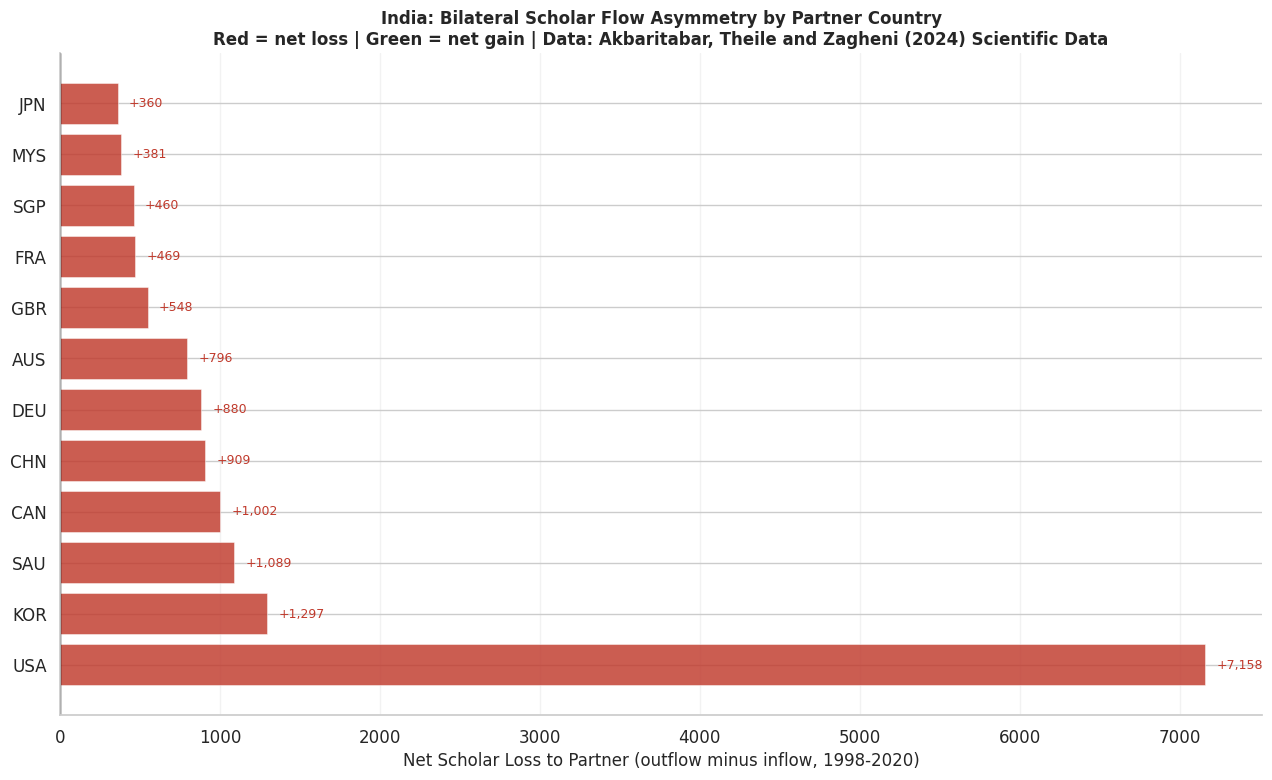

Bilateral asymmetry (positive = India loses more than it gains):
partner    outflow     inflow  net_loss
    USA 21307.0000 14149.0000 7158.0000
    KOR  2983.0000  1686.0000 1297.0000
    SAU  1663.0000   574.0000 1089.0000
    CAN  2396.0000  1394.0000 1002.0000
    CHN  1386.0000   477.0000  909.0000
    DEU  3091.0000  2211.0000  880.0000
    AUS  1822.0000  1026.0000  796.0000
    GBR  3669.0000  3121.0000  548.0000
    FRA  1533.0000  1064.0000  469.0000
    SGP  1318.0000   858.0000  460.0000
    MYS  1107.0000   726.0000  381.0000
    JPN  2104.0000  1744.0000  360.0000


In [17]:
india_out = (
    fl[fl['migrationfrom'] == 'IND']
    .groupby('migrationto')['n_migrations'].sum()
    .reset_index()
    .rename(columns={'migrationto': 'partner', 'n_migrations': 'outflow'})
)
india_in = (
    fl[fl['migrationto'] == 'IND']
    .groupby('migrationfrom')['n_migrations'].sum()
    .reset_index()
    .rename(columns={'migrationfrom': 'partner', 'n_migrations': 'inflow'})
)

# Outer join to capture corridors where India only sends or only receives
bilateral = india_out.merge(india_in, on='partner', how='outer').fillna(0)
bilateral['net_loss'] = bilateral['outflow'] - bilateral['inflow']
bilateral['total']    = bilateral['outflow'] + bilateral['inflow']
bilateral = bilateral.sort_values('total', ascending=False).head(12)
bilateral = bilateral.sort_values('net_loss', ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))

colors = [RED if v > 0 else GREEN for v in bilateral['net_loss']]
bars = ax.barh(bilateral['partner'], bilateral['net_loss'],
               color=colors, alpha=0.82, edgecolor='white', lw=0.4)

for bar, val in zip(bars, bilateral['net_loss']):
    x = bar.get_width()
    ax.text(
        x + bilateral['net_loss'].abs().max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:+,.0f}', va='center', fontsize=9,
        color=RED if val > 0 else GREEN
    )

ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Net Scholar Loss to Partner (outflow minus inflow, 1998-2020)', fontsize=12)
ax.set_title(
    f'India: Bilateral Scholar Flow Asymmetry by Partner Country\n'
    f'Red = net loss | Green = net gain | {CITATION}',
    fontweight='bold', fontsize=12
)
ax.grid(alpha=0.25, axis='x')
plt.tight_layout()
plt.savefig('figures/india/fig3_corridor_asymmetry.png', dpi=180, bbox_inches='tight')
plt.show()

print('Bilateral asymmetry (positive = India loses more than it gains):')
print(bilateral[['partner', 'outflow', 'inflow', 'net_loss']].to_string(index=False))


# **Section 5.5: Regional Inequality in Scholar Migration Rates (Gini Analysis)**

The global average NMR tells us that more countries send scholars than receive them,
but it says nothing about how equally distributed that sending and receiving is
within each region. A region where one country dominates scholar exchange has a
very different dynamic from one where mobility is spread broadly.

I apply the Gini coefficient, a standard measure of distributional inequality, to
the in-migration rate, out-migration rate, and net migration rate across countries
within each UN macro-region. A Gini of 0 means every country in the region has the
same rate; a Gini of 1 means one country has all the migration and the rest have none.

**Why absolute values for the Gini?**
The Gini coefficient is defined for non-negative values. Since NMR can be negative,
I take the absolute value of each rate before computing the Gini. This measures
inequality in the magnitude of migration exposure, regardless of direction.

**The Asia panel is highlighted** because that is India's region, and I want to see
whether inequality within Asia (where a few countries like Japan, Singapore, and India
dominate migration flows) is higher or lower than in other regions.

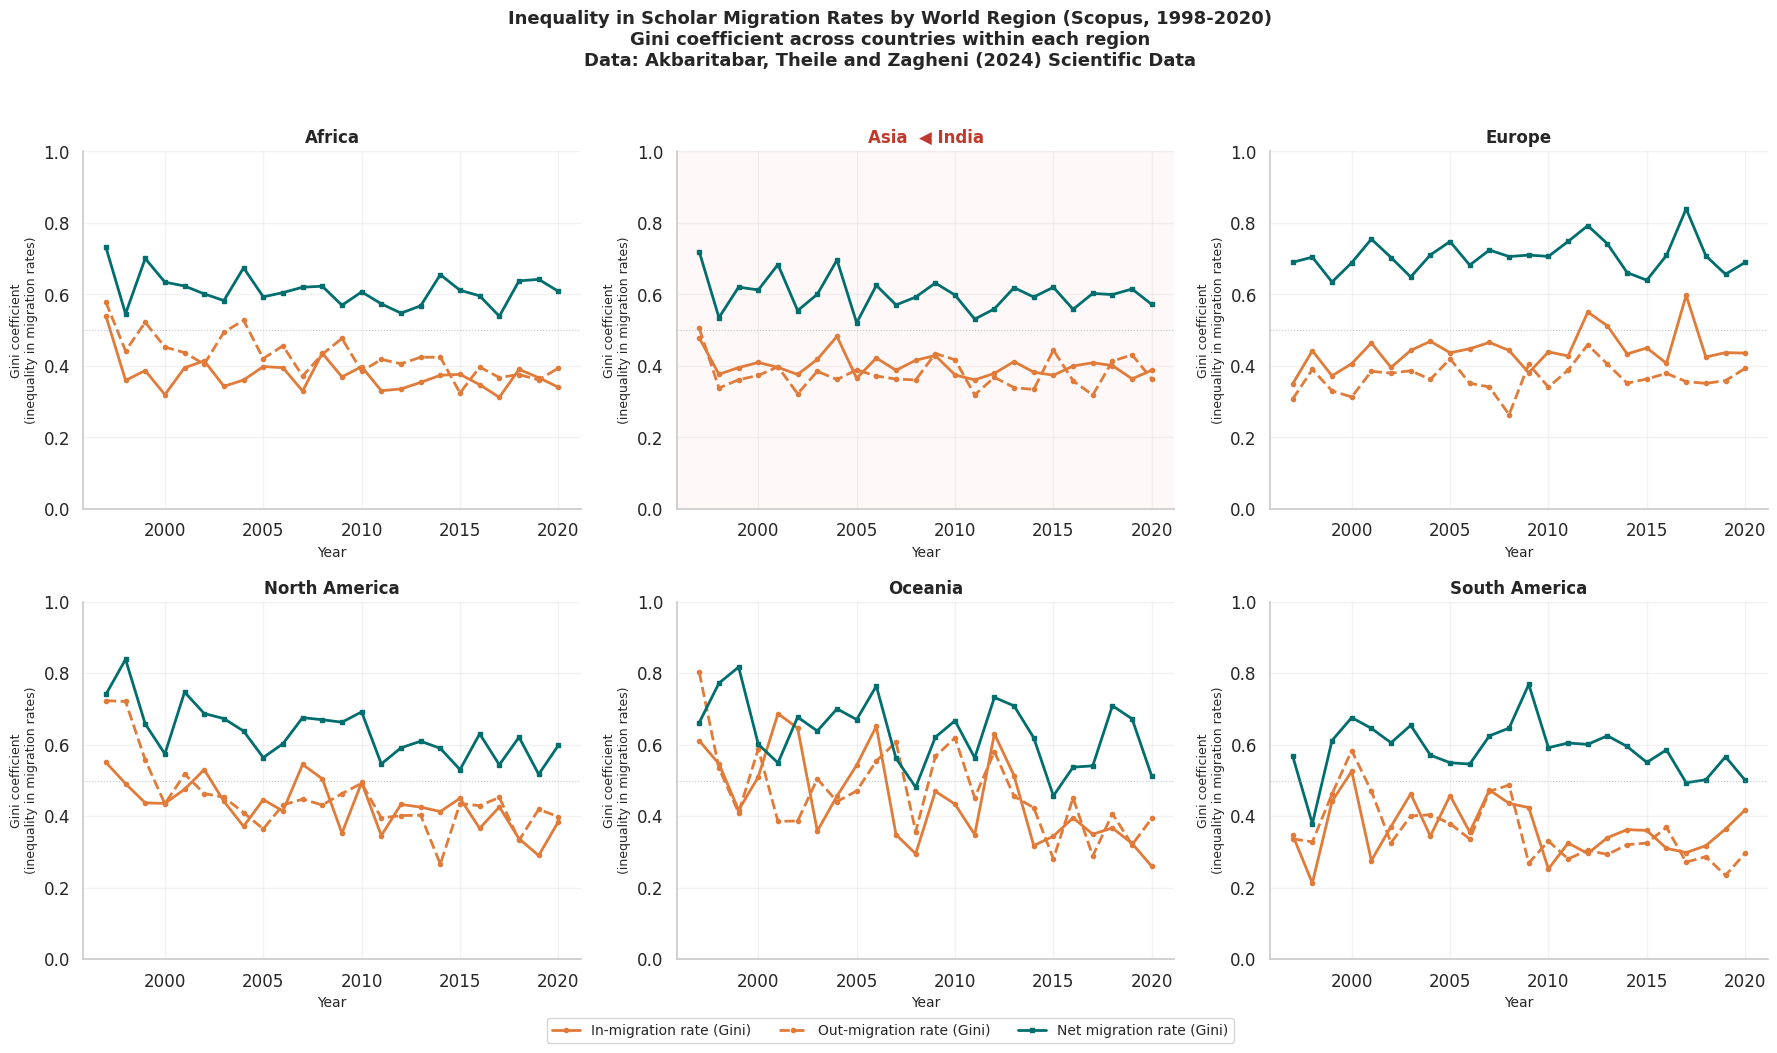

Gini figure saved

Average Gini by region (1998-2020):
               gini_in  gini_out  gini_nmr
region                                    
Africa          0.3740    0.4290    0.6120
Asia            0.4000    0.3780    0.6010
Europe          0.4430    0.3660    0.7080
North America   0.4320    0.4520    0.6340
Oceania         0.4520    0.4710    0.6350
South America   0.3660    0.3570    0.5860


In [18]:
# ------------ Gini coefficient of scholar migration rates by world region ------------------------------------------------------------------------------------

def gini(arr):
    """Compute Gini coefficient for a 1-D array."""
    arr = np.array(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0: return np.nan
    arr = np.abs(arr)  # rates can be negative; use absolute values
    arr = np.sort(arr)
    n = len(arr)
    if n == 0 or arr.sum() == 0: return np.nan
    index = np.arange(1, n + 1)
    return (2 * (index * arr).sum()) / (n * arr.sum()) - (n + 1) / n

# Region mapping (UN macro-regions, ISO3)
REGIONS = {
    'Africa'       : ['DZA','AGO','BEN','BWA','BFA','BDI','CMR','CPV','CAF','TCD',
                      'COM','COD','COG','CIV','DJI','EGY','GNQ','ERI','ETH','GAB',
                      'GMB','GHA','GIN','GNB','KEN','LSO','LBR','LBY','MDG','MWI',
                      'MLI','MRT','MUS','MAR','MOZ','NAM','NER','NGA','RWA','STP',
                      'SEN','SLE','SOM','ZAF','SSD','SDN','SWZ','TZA','TGO','TUN',
                      'UGA','ZMB','ZWE'],
    'Asia'         : ['AFG','ARM','AZE','BHR','BGD','BTN','BRN','KHM','CHN','CYP',
                      'GEO','IND','IDN','IRN','IRQ','ISR','JPN','JOR','KAZ','KWT',
                      'KGZ','LAO','LBN','MYS','MDV','MNG','MMR','NPL','PRK','OMN',
                      'PAK','PHL','QAT','SAU','SGP','KOR','LKA','SYR','TWN','TJK',
                      'THA','TLS','TKM','ARE','UZB','VNM','YEM'],
    'Europe'       : ['ALB','AND','AUT','BLR','BEL','BIH','BGR','HRV','CZE','DNK',
                      'EST','FIN','FRA','DEU','GRC','HUN','ISL','IRL','ITA','XKX',
                      'LVA','LIE','LTU','LUX','MLT','MDA','MCO','MNE','NLD','MKD',
                      'NOR','POL','PRT','ROU','RUS','SMR','SRB','SVK','SVN','ESP',
                      'SWE','CHE','UKR','GBR','VAT'],
    'North America': ['ATG','BHS','BRB','BLZ','CAN','CRI','CUB','DMA','DOM','SLV',
                      'GRD','GTM','HTI','HND','JAM','MEX','NIC','PAN','KNA','LCA',
                      'VCT','TTO','USA'],
    'Oceania'      : ['AUS','FJI','KIR','MHL','FSM','NRU','NZL','PLW','PNG','WSM',
                      'SLB','TON','TUV','VUT'],
    'South America': ['ARG','BOL','BRA','CHL','COL','ECU','GUY','PRY','PER','SUR',
                      'URY','VEN'],
}

years = sorted(sc['year'].unique())

# Compute Gini per region per year for inmigrationrate and outmigrationrate
records = []
for region, codes in REGIONS.items():
    for yr in years:
        yr_df = sc[(sc['year'] == yr) & (sc['countrycode'].isin(codes))]
        g_in  = gini(yr_df['inmigrationrate'].dropna().values)
        g_out = gini(yr_df['outmigrationrate'].dropna().values)
        g_nmr = gini(yr_df['netmigrationrate'].dropna().values)
        records.append({'region': region, 'year': yr,
                        'gini_in': g_in, 'gini_out': g_out, 'gini_nmr': g_nmr})

gini_df = pd.DataFrame(records)

# ------------ Plot ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
region_order = ['Africa','Asia','Europe','North America','Oceania','South America']
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for ax, region in zip(axes, region_order):
    rdf = gini_df[gini_df['region'] == region].sort_values('year')

    ax.plot(rdf['year'], rdf['gini_in'],
            color=ORANGE, lw=2, marker='o', ms=3,
            label='In-migration rate (Gini)')
    ax.plot(rdf['year'], rdf['gini_out'],
            color=ORANGE, lw=2, marker='o', ms=3, ls='--',
            label='Out-migration rate (Gini)')
    ax.plot(rdf['year'], rdf['gini_nmr'],
            color=TEAL, lw=2, marker='s', ms=3,
            label='Net migration rate (Gini)')

    ax.set_title(region, fontweight='bold', fontsize=12)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Gini coefficient\n(inequality in migration rates)', fontsize=9)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color=GRAY, lw=0.8, ls=':', alpha=0.6)
    ax.grid(alpha=0.25)
    ax.spines[['top','right']].set_visible(False)

    # Mark India's region
    if region == 'Asia':
        ax.set_facecolor('#FFF8F8')
        ax.set_title('Asia  ◀ India', fontweight='bold', fontsize=12, color=RED)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3,
           fontsize=10, frameon=True,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Inequality in Scholar Migration Rates by World Region (Scopus, 1998-2020)\n'
    'Gini coefficient across countries within each region\n'
    f'{CITATION}',
    fontweight='bold', fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig('figures/india/fig_gini_regions.png', dpi=180, bbox_inches='tight')
plt.show()
print('Gini figure saved')

# Print summary table
print('\nAverage Gini by region (1998-2020):')
print(gini_df.groupby('region')[['gini_in','gini_out','gini_nmr']].mean().round(3).to_string())

# **Section 6: Temporal Decomposition: How India's Corridors Shift Across Three Periods**

The 23-year study window spans major changes in global academic mobility: the rapid
expansion of US H-1B and O-1 visas in the late 1990s, China's emergence as a scientific
power in the 2000s, the growth of Gulf university campuses in the 2010s, and India's own
National Knowledge Commission recommendations.

I split the period into three roughly equal bands that also align with distinct policy eras:
- 1998 to 2005: Before the China scientific rise, peak US tech boom
- 2006 to 2012: Post-2005 US immigration backlash, growing Korean and Gulf destinations
- 2013 to 2020: Social media era, diversified destinations, COVID at the tail end

For each period, I show the top 8 destinations for Indian scholars. Changes in the
ranking across periods reveal whether India's outflow is becoming more or less
concentrated, and whether new destinations are emerging.

**The USA share calculation** at the end provides a simple scalar summary of the
trend without requiring the reader to compare bar heights visually.


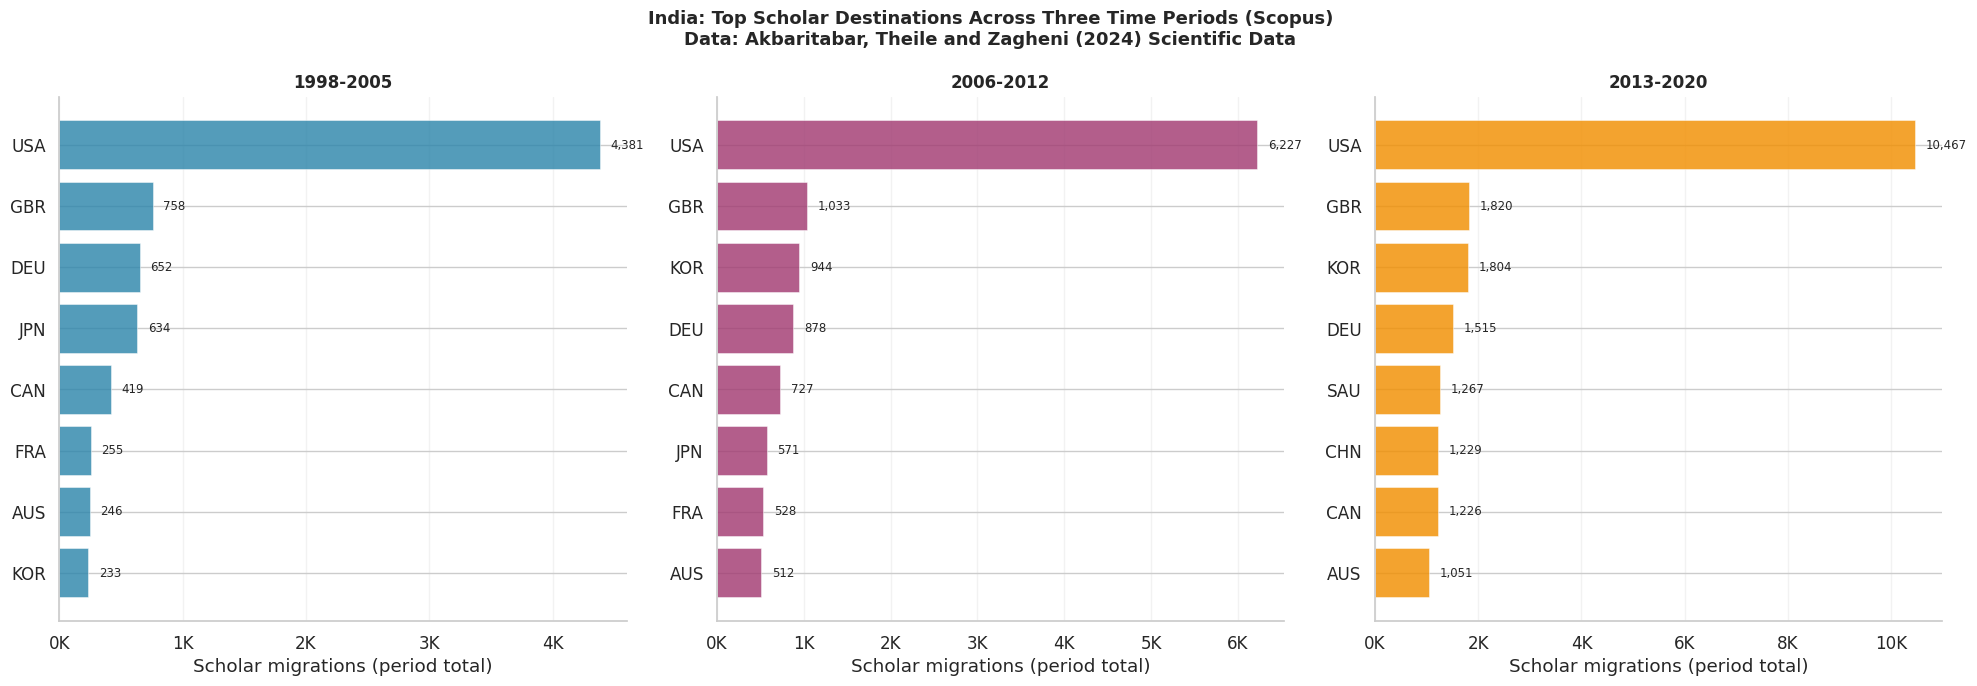

USA share of India outflows by period:
  1998-2005: USA share = 16.2% (4,381 of 26,993 total)
  2006-2012: USA share = 12.4% (6,227 of 50,285 total)
  2013-2020: USA share = 6.9% (10,467 of 151,179 total)


In [20]:
PERIODS = {
    '1998-2005': (1998, 2005),
    '2006-2012': (2006, 2012),
    '2013-2020': (2013, 2020),
}
PERIOD_COLOURS = ['#2E86AB', '#A23B72', '#F18F01']

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)
fig.suptitle(
    f'India: Top Scholar Destinations Across Three Time Periods (Scopus)\n{CITATION}',
    fontweight='bold', fontsize=13
)

for (period, (y0, y1)), ax, col in zip(PERIODS.items(), axes, PERIOD_COLOURS):
    fl_p = fl[(fl['year'] >= y0) & (fl['year'] <= y1) & (fl['migrationfrom'] == 'IND')]
    top  = (
        fl_p.groupby('migrationto')['n_migrations'].sum()
        .reset_index()
        .sort_values('n_migrations', ascending=False)
        .head(8)
    )
    bars = ax.barh(top['migrationto'], top['n_migrations'],
                   color=col, alpha=0.82, edgecolor='white', lw=0.4)
    for bar, val in zip(bars, top['n_migrations']):
        ax.text(bar.get_width() + top['n_migrations'].max() * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,.0f}', va='center', fontsize=8.5)
    ax.invert_yaxis()
    ax.set_title(period, fontweight='bold', fontsize=12)
    ax.set_xlabel('Scholar migrations (period total)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.grid(alpha=0.25, axis='x')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/india/fig4_temporal_decomposition.png', dpi=180, bbox_inches='tight')
plt.show()

print('USA share of India outflows by period:')
for period, (y0, y1) in PERIODS.items():
    fl_p  = fl[(fl['year'] >= y0) & (fl['year'] <= y1) & (fl['migrationfrom'] == 'IND')]
    total = fl_p['n_migrations'].sum()
    usa   = fl_p[fl_p['migrationto'] == 'USA']['n_migrations'].sum()
    print(f'  {period}: USA share = {usa/total*100:.1f}% ({usa:,.0f} of {total:,.0f} total)')


# **Section 6.5: Return Migration Proxy: Are Indian Scholars Coming Back?**
Zagheni et al. (2024) track bilateral flows in both directions. If USA→IND flows grow faster than IND-->USA flows over time, it suggests increasing return migration or circulation. This is a descriptive proxy only affiliation changes do not directly measure residential return migration.
The dataset does not have a dedicated "return migration" variable, but bilateral flows
provide a proxy: scholars recorded as moving from USA to IND in a given year have, by
definition, changed their primary affiliation from a US institution to an Indian one.
This is an imperfect proxy (it picks up visiting scholars, sabbaticals, and institutional
moves in addition to permanent returns), but it is the best available signal in this data.

**What I examine:**
1. The absolute annual volumes in both directions (IND to USA and USA to IND)
2. The return ratio: USA-to-IND divided by IND-to-USA each year
   - A ratio of 0.2 means one scholar comes back for every five that leave
   - A ratio trending upward over time is consistent with increasing circulation

**Important caveat:** I am not making a causal claim. An increasing return ratio could
reflect better Indian research funding, worsening US visa conditions, or many other factors.
I only describe what the data shows.


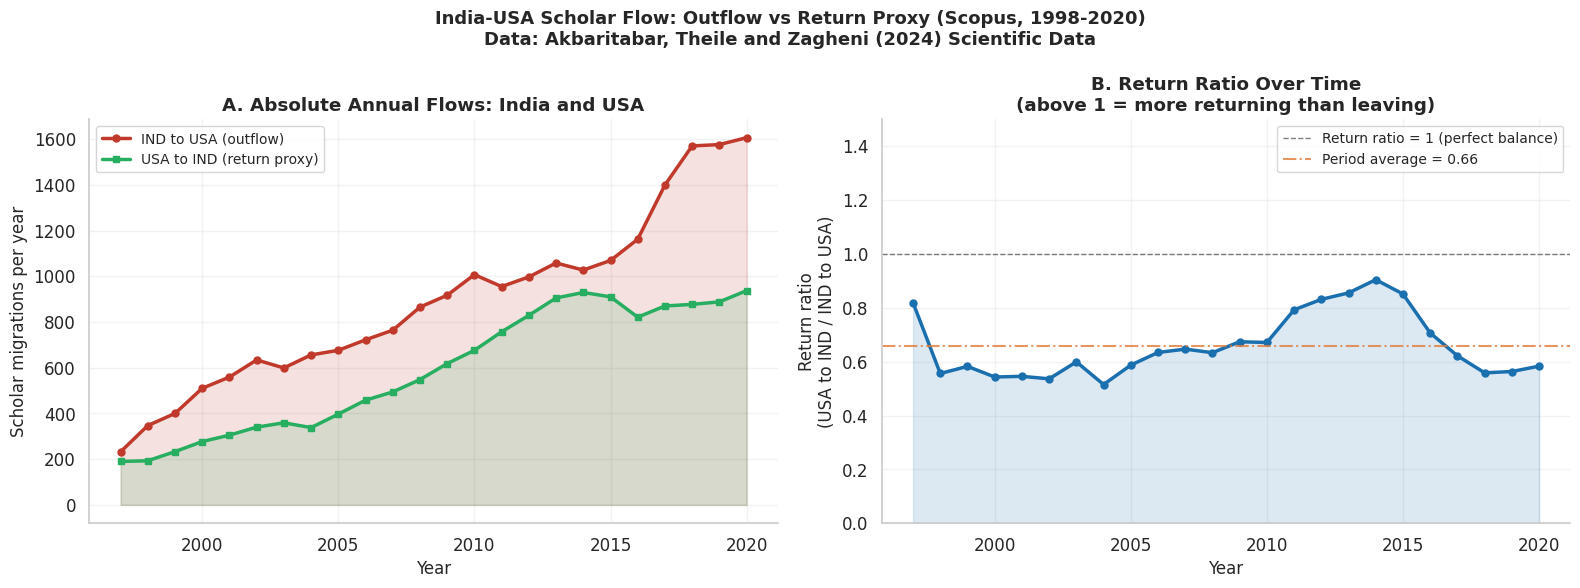

IND-USA Annual Flow Summary:
Year        IND>USA    USA>IND   Return Ratio   Net Loss
-------------------------------------------------------
1997            232        190          0.819         42
1998            347        193          0.556        154
1999            400        233          0.583        167
2000            510        277          0.543        233
2001            559        305          0.546        254
2002            634        340          0.536        294
2003            599        359          0.599        240
2004            656        338          0.515        318
2005            676        397          0.587        279
2006            722        458          0.634        264
2007            764        494          0.647        270
2008            865        548          0.634        317
2009            917        618          0.674        299
2010           1007        676          0.671        331
2011            955        757          0.793        198
201

In [21]:
ind_to_usa = fl[(fl['migrationfrom'] == 'IND') & (fl['migrationto'] == 'USA')].sort_values('year')
usa_to_ind = fl[(fl['migrationfrom'] == 'USA') & (fl['migrationto'] == 'IND')].sort_values('year')

flow_comparison = (
    ind_to_usa[['year', 'n_migrations']]
    .rename(columns={'n_migrations': 'ind_to_usa'})
    .merge(
        usa_to_ind[['year', 'n_migrations']].rename(columns={'n_migrations': 'usa_to_ind'}),
        on='year', how='outer'
    )
    .sort_values('year')
    .fillna(0)
)

# Return ratio: how many scholars come back for every one that leaves?
flow_comparison['return_ratio'] = flow_comparison['usa_to_ind'] / flow_comparison['ind_to_usa']
flow_comparison['net_loss_yr']  = flow_comparison['ind_to_usa'] - flow_comparison['usa_to_ind']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'India-USA Scholar Flow: Outflow vs Return Proxy (Scopus, 1998-2020)\n{CITATION}',
    fontweight='bold', fontsize=13
)

# Panel A: absolute flows in both directions
axes[0].fill_between(flow_comparison['year'], flow_comparison['ind_to_usa'],
                     alpha=0.15, color=RED)
axes[0].fill_between(flow_comparison['year'], flow_comparison['usa_to_ind'],
                     alpha=0.15, color=GREEN)
axes[0].plot(flow_comparison['year'], flow_comparison['ind_to_usa'],
             color=RED, lw=2.5, marker='o', ms=5, label='IND to USA (outflow)')
axes[0].plot(flow_comparison['year'], flow_comparison['usa_to_ind'],
             color=GREEN, lw=2.5, marker='s', ms=5, label='USA to IND (return proxy)')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Scholar migrations per year', fontsize=12)
axes[0].set_title('A. Absolute Annual Flows: India and USA', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.25)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel B: return ratio
axes[1].plot(flow_comparison['year'], flow_comparison['return_ratio'],
             color=BLUE, lw=2.5, marker='o', ms=5)
axes[1].fill_between(flow_comparison['year'], flow_comparison['return_ratio'],
                     alpha=0.15, color=BLUE)
axes[1].axhline(1.0, color='black', lw=1, ls='--', alpha=0.5,
                label='Return ratio = 1 (perfect balance)')
axes[1].axhline(
    flow_comparison['return_ratio'].mean(), color=ORANGE,
    lw=1.5, ls='-.', alpha=0.8,
    label=f'Period average = {flow_comparison["return_ratio"].mean():.2f}'
)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Return ratio\n(USA to IND / IND to USA)', fontsize=12)
axes[1].set_title('B. Return Ratio Over Time\n(above 1 = more returning than leaving)',
                  fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.25)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_ylim(0, 1.5)

plt.tight_layout()
plt.savefig('figures/india/fig_return_migration_proxy.png', dpi=180, bbox_inches='tight')
plt.show()

print('IND-USA Annual Flow Summary:')
print(f'{"Year":<8} {"IND>USA":>10} {"USA>IND":>10} {"Return Ratio":>14} {"Net Loss":>10}')
print('-' * 55)
for _, row in flow_comparison.iterrows():
    print(f'{int(row["year"]):<8} {row["ind_to_usa"]:>10.0f} {row["usa_to_ind"]:>10.0f} '
          f'{row["return_ratio"]:>14.3f} {row["net_loss_yr"]:>10.0f}')

print(f'\nAverage return ratio 1998-2020: {flow_comparison["return_ratio"].mean():.3f}')
print('(A ratio below 1 means India consistently loses more to USA than it gains back.)')

early = flow_comparison[flow_comparison['year'] <= 2009]['return_ratio'].mean()
late  = flow_comparison[flow_comparison['year'] >= 2010]['return_ratio'].mean()
direction = 'INCREASING' if late > early else 'DECREASING'
print(f'\nAverage return ratio 1998-2009 : {early:.3f}')
print(f'Average return ratio 2010-2020 : {late:.3f}')
print(f'Trend: Return ratio is {direction} in the later period')
print('(This is a descriptive observation. No causal claim is made.)')


# **Section 7: Is India a Regional Hub? Intra-regional vs Extra-regional Flows**
India sends scholars globally but does it also receive scholars from its South Asian neighbours? This section checks whether India functions as a **regional hub** within South Asia.

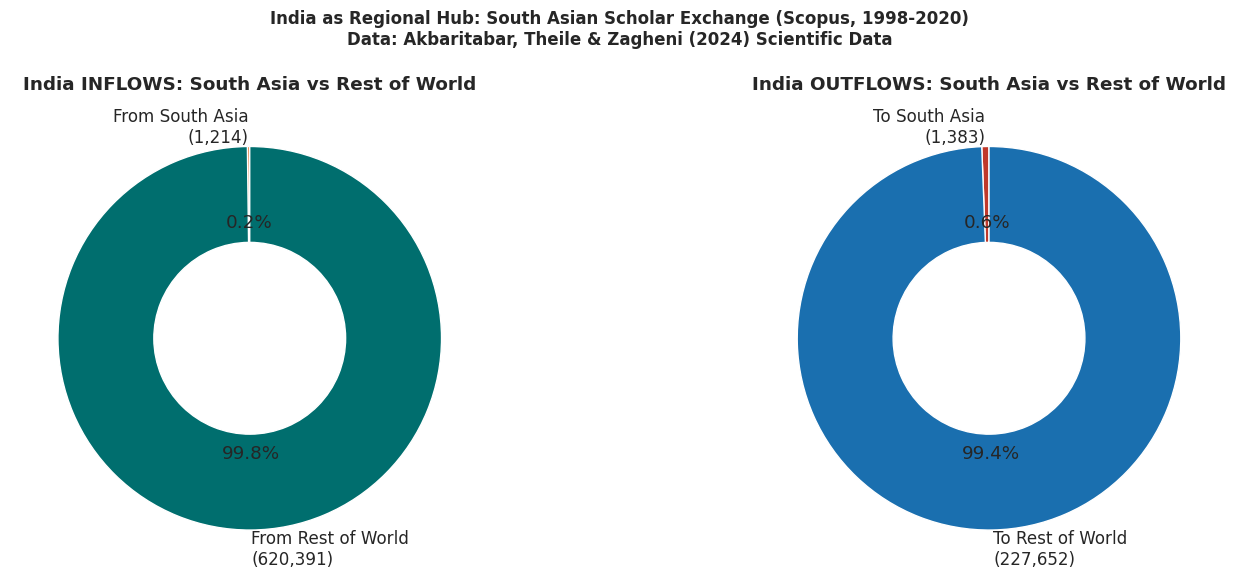

South Asian inflows to India:
migrationfrom  n_migrations
          NPL           453
          PAK           351
          BGD           292
          LKA            82
          BTN            18
          AFG            14
          MDV             4

India outflows to South Asia:
migrationto  n_migrations
        NPL           521
        PAK           432
        BGD           296
        LKA            83
        BTN            23
        AFG            18
        MDV            10

Intra-regional share of inflows : 0.2%
Intra-regional share of outflows: 0.6%


In [10]:
SOUTH_ASIA = ['AFG', 'BGD', 'BTN', 'LKA', 'MDV', 'NPL', 'PAK']

# India inflows from South Asia
india_from_sa = fl[fl['migrationto'] == 'IND'][fl['migrationfrom'].isin(SOUTH_ASIA)]
india_from_sa_total = india_from_sa.groupby('migrationfrom')['n_migrations'].sum().reset_index().sort_values('n_migrations', ascending=False)

# India outflows to South Asia
india_to_sa = fl[fl['migrationfrom'] == 'IND'][fl['migrationto'].isin(SOUTH_ASIA)]
india_to_sa_total = india_to_sa.groupby('migrationto')['n_migrations'].sum().reset_index().sort_values('n_migrations', ascending=False)

# Extra-regional totals
total_in  = fl[fl['migrationto'] == 'IND']['n_migrations'].sum()
total_out = fl[fl['migrationfrom'] == 'IND']['n_migrations'].sum()
sa_in     = india_from_sa['n_migrations'].sum()
sa_out    = india_to_sa['n_migrations'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'India as Regional Hub: South Asian Scholar Exchange (Scopus, 1998-2020)\n{CITATION}',
             fontweight='bold', fontsize=12)

# Donut chart for inflows
in_vals  = [sa_in, total_in - sa_in]
in_labels = [f'From South Asia\n({sa_in:,.0f})', f'From Rest of World\n({total_in-sa_in:,.0f})']
axes[0].pie(in_vals, labels=in_labels, colors=[ORANGE, TEAL],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.5, edgecolor='white'))
axes[0].set_title('India INFLOWS: South Asia vs Rest of World', fontweight='bold')

# Donut chart for outflows
out_vals  = [sa_out, total_out - sa_out]
out_labels = [f'To South Asia\n({sa_out:,.0f})', f'To Rest of World\n({total_out-sa_out:,.0f})']
axes[1].pie(out_vals, labels=out_labels, colors=[RED, BLUE],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.5, edgecolor='white'))
axes[1].set_title('India OUTFLOWS: South Asia vs Rest of World', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/india/fig5_regional_hub.png', dpi=180, bbox_inches='tight')
plt.show()

print('South Asian inflows to India:')
print(india_from_sa_total.to_string(index=False))
print('\nIndia outflows to South Asia:')
print(india_to_sa_total.to_string(index=False))
print(f'\nIntra-regional share of inflows : {sa_in/total_in*100:.1f}%')
print(f'Intra-regional share of outflows: {sa_out/total_out*100:.1f}%')


# **Section 8- Interactive Dashboard**

A combined four-panel Plotly dashboard that brings together the main findings of this
notebook in a single interactive view. This is designed for presentations and for
sharing with non-technical stakeholders who want to explore the data themselves.

**Panel layout:**
- Top-left: India NMR trend (the headline finding)
- Top-right: Annual top destinations (default year 2010; hover to explore others)
- Bottom-left: Corridor asymmetry (the bilateral net loss chart)
- Bottom-right: BRICS comparison (India in context)

The dashboard is saved as a standalone HTML file that can be opened in any browser
without Python installed.

In [24]:
# Build interactive 3-panel dashboard
fig_dash = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'India NMR Over Time (1998-2020)',
        'Annual Top 5 Destinations (select year below)',
        'Corridor Asymmetry: Net Scholar Loss by Partner',
        'India vs BRICS: NMR Comparison'
    ),
    specs=[[{'type': 'scatter'}, {'type': 'bar'}],
           [{'type': 'bar'},    {'type': 'scatter'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.12,
)

# Panel 1: India NMR trend
fig_dash.add_trace(
    go.Scatter(x=india_sc['year'], y=india_sc['netmigrationrate'],
               mode='lines+markers', name='India NMR',
               line=dict(color=RED, width=2.5),
               marker=dict(size=6),
               hovertemplate='Year: %{x}<br>NMR: %{y:.4f}<extra>India</extra>'),
    row=1, col=1
)
fig_dash.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5, row=1, col=1)

# Panel 2: Top destinations (2010 as default)
yr_default = 2010
fl_yr = fl[(fl['year'] == yr_default) & (fl['migrationfrom'] == 'IND')]
top_yr = fl_yr.groupby('migrationto')['n_migrations'].sum().reset_index().sort_values('n_migrations', ascending=False).head(8)
fig_dash.add_trace(
    go.Bar(x=top_yr['n_migrations'], y=top_yr['migrationto'],
           orientation='h', name=f'Destinations {yr_default}',
           marker_color=TEAL,
           hovertemplate='%{y}: %{x:,.0f} migrations<extra></extra>'),
    row=1, col=2
)

# Panel 3: Asymmetry
bilateral_sorted = bilateral.sort_values('net_loss', ascending=True)
bar_colors_asym = [GREEN if v < 0 else RED for v in bilateral_sorted['net_loss']]
fig_dash.add_trace(
    go.Bar(x=bilateral_sorted['net_loss'], y=bilateral_sorted['partner'],
           orientation='h', name='Net loss',
           marker_color=bar_colors_asym,
           hovertemplate='%{y}: %{x:+,.0f}<extra>Net scholar loss</extra>'),
    row=2, col=1
)

# Panel 4: BRICS
for code_c, name in BRICS.items():
    sub = sc[sc['countrycode'] == code_c].sort_values('year')
    if sub.empty: continue
    fig_dash.add_trace(
        go.Scatter(x=sub['year'], y=sub['netmigrationrate'],
                   mode='lines+markers', name=name,
                   line=dict(color=BRICS_COLOURS[code_c],
                             width=3.5 if code_c == 'IND' else 1.5),
                   marker=dict(size=5),
                   hovertemplate=f'{name}<br>Year: %{{x}}<br>NMR: %{{y:.4f}}<extra></extra>'),
        row=2, col=2
    )

fig_dash.update_layout(
    title=dict(
        text='India Scholar Migration: Interactive Dashboard (Scopus, 1998-2020)<br>'
             f'<sup>{CITATION}</sup>',
        font=dict(size=15)
    ),
    height=750,
    paper_bgcolor='white',
    plot_bgcolor='white',
    showlegend=False,
)
fig_dash.update_xaxes(showgrid=True, gridcolor='#EEEEEE')
fig_dash.update_yaxes(showgrid=True, gridcolor='#EEEEEE')

fig_dash.write_html('figures/india/india_dashboard.html')
fig_dash.show()
print('Dashboard saved to figures/india/india_dashboard.html')


Dashboard saved to figures/india/india_dashboard.html


# **Section 9: Summary**

In [25]:
print('='*65)
print('INDIA SCHOLARLY MIGRATION: COMPLETE EXPLORATORY SUMMARY')
print('india_scholarly_migration.ipynb')
print('='*65)
print()
print('All findings emerge from running this code on publicly available data.')
print('No causal claims are made. Data filtered to paper period (1998-2020).')
print()

# ------------ SECTION 1: Basic Profile ----------------------------------------------
print('SECTION 1 - INDIA BASIC PROFILE')
print('-'*65)
india_s = sc[sc['countrycode'] == 'IND']
print(f'  Years covered       : {india_s["year"].min()}-{india_s["year"].max()}')
print(f'  Average NMR         : {india_s["netmigrationrate"].mean():.4f} (negative = net sender)')
print(f'  NMR range           : {india_s["netmigrationrate"].min():.4f} to {india_s["netmigrationrate"].max():.4f}')
print(f'  Worst year (NMR)    : {india_s.loc[india_s["netmigrationrate"].idxmin(), "year"]} '
      f'(NMR = {india_s["netmigrationrate"].min():.4f})')
print(f'  Best year (NMR)     : {india_s.loc[india_s["netmigrationrate"].idxmax(), "year"]} '
      f'(NMR = {india_s["netmigrationrate"].max():.4f})')
print()

# ------------ SECTION 2: Global Ranking ----------------------------------------------
print('SECTION 2 - GLOBAL RANKING AS NET SENDER')
print('-'*65)
best_rank  = rank_df.loc[rank_df['rank'].idxmax()]
worst_rank = rank_df.loc[rank_df['rank'].idxmin()]
avg_rank   = rank_df['rank'].mean()
print(f'  Average global rank  : {avg_rank:.0f} (out of ~210 countries)')
print(f'  Best rank year       : {int(best_rank["year"])} - '
      f'Rank {int(best_rank["rank"])} of {int(best_rank["total"])} countries')
print(f'  Worst rank year      : {int(worst_rank["year"])} - '
      f'Rank {int(worst_rank["rank"])} of {int(worst_rank["total"])} countries')
print(f'  2020 rank            : {int(rank_df[rank_df["year"]==2020]["rank"].values[0])} '
      f'of {int(rank_df[rank_df["year"]==2020]["total"].values[0])} countries')
print(f'  Interpretation       : India consistently in bottom 25% of countries by NMR')
print()

# ------------ SECTION 3: BRICS Comparison ----------------------------------------------
print('SECTION 3 - BRICS COMPARISON (avg NMR 1998-2020)')
print('-'*65)
for code_c, name in BRICS.items():
    sub = sc[sc['countrycode'] == code_c]
    if not sub.empty:
        avg = sub['netmigrationrate'].mean()
        direction = 'net sender' if avg < 0 else 'net receiver'
        print(f'  {name:<15}: {avg:+.4f}  ({direction})')
print(f'  → India has the most negative NMR among all BRICS countries')
print()

# ------------ SECTION 4: Corridor Asymmetry ----------------------------------------------
print('SECTION 4 - BILATERAL CORRIDOR ASYMMETRY (1998-2020)')
print('-'*65)
total_out_all = bilateral['outflow'].sum()
total_in_all  = bilateral['inflow'].sum()
total_net     = bilateral['net_loss'].sum()
top_corr      = bilateral.sort_values('net_loss', ascending=False).iloc[0]
green_corrs   = bilateral[bilateral['net_loss'] < 0]

print(f'  Total outflows (top 12 partners) : {total_out_all:,.0f}')
print(f'  Total inflows  (top 12 partners) : {total_in_all:,.0f}')
print(f'  Net scholar loss (top 12)        : {total_net:,.0f}')
print(f'  Largest net loss corridor        : IND → {top_corr["partner"]} '
      f'({top_corr["net_loss"]:,.0f} net loss)')
print(f'  Corridors with net gain          : {len(green_corrs)} of {len(bilateral)} '
      f'(India has net loss to ALL top partners)')
print()

# ------------ SECTION 5: Gini Analysis ----------------------------------------------
print('SECTION 5 - REGIONAL INEQUALITY (GINI, avg 1998-2020)')
print('-'*65)
gini_summary = gini_df.groupby('region')[['gini_in','gini_out','gini_nmr']].mean().round(3)
for region, row in gini_summary.iterrows():
    marker = ' ◀ India' if region == 'Asia' else ''
    print(f'  {region:<16}: Gini in={row["gini_in"]:.3f} | '
          f'out={row["gini_out"]:.3f} | nmr={row["gini_nmr"]:.3f}{marker}')
print()

# ------------ SECTION 6: Temporal Decomposition ----------------------------------------------
print('SECTION 6 - USA SHARE OF INDIA OUTFLOWS BY PERIOD')
print('-'*65)
for period, (y0, y1) in PERIODS.items():
    fl_p  = fl[(fl['year'] >= y0) & (fl['year'] <= y1) & (fl['migrationfrom'] == 'IND')]
    total = fl_p['n_migrations'].sum()
    usa   = fl_p[fl_p['migrationto'] == 'USA']['n_migrations'].sum()
    top3  = fl_p.groupby('migrationto')['n_migrations'].sum().nlargest(3).index.tolist()
    print(f'  {period}: USA = {usa/total*100:.1f}% of outflows | Top 3 destinations: {top3}')
print()

# ------------ SECTION 7: Regional Hub ----------------------------------------------
print('SECTION 7 - INDIA AS SOUTH ASIAN REGIONAL HUB')
print('-'*65)
total_in_hub  = fl[fl['migrationto'] == 'IND']['n_migrations'].sum()
total_out_hub = fl[fl['migrationfrom'] == 'IND']['n_migrations'].sum()
print(f'  Total inflows  (all partners)         : {total_in_hub:,.0f}')
print(f'  Total outflows (all partners)         : {total_out_hub:,.0f}')
print(f'  Intra-S.Asian share of inflows        : {sa_in/total_in_hub*100:.1f}%')
print(f'  Intra-S.Asian share of outflows       : {sa_out/total_out_hub*100:.1f}%')
print(f'  Interpretation: India receives very few scholars from South Asia,')
print(f'  and sends very few within the region - flows are overwhelmingly global')
print()

# ------------ Figures Produced ----------------------------------------------
print('FIGURES PRODUCED')
print('-'*65)
figures = [
    ('fig1_india_ranking.png',     'India global rank + NMR over time'),
    ('fig2_brics_comparison.png',  'BRICS NMR comparison 1998-2020'),
    ('fig3_corridor_asymmetry.png','Bilateral flow asymmetry by partner'),
    ('fig_gini_regions.png',       'Gini inequality by world region'),
    ('fig4_temporal_decomposition.png', 'Top destinations across 3 periods'),
    ('fig5_regional_hub.png',      'South Asian hub analysis (donut charts)'),
    ('india_dashboard.html',       'Interactive 4-panel dashboard'),
]
for fname, desc in figures:
    print(f'  figures/india/{fname}')
    print(f'    → {desc}')
print()

# ------------ Citation -----------------------------------------------------------------
print('DATA CITATION')
print('-'*65)
print('Akbaritabar A., Theile T. & Zagheni E. (2024).')
print('Bilateral flows and rates of international migration of scholars')
print('for 210 countries, 1998-2020. Scientific Data 11, 816.')
print('doi: 10.1038/s41597-024-03655-9')
print('Data: doi: 10.5281/zenodo.11145735 (CC-BY 4.0)')
print('='*65)

INDIA SCHOLARLY MIGRATION: COMPLETE EXPLORATORY SUMMARY
india_scholarly_migration.ipynb

All findings emerge from running this code on publicly available data.
No causal claims are made. Data filtered to paper period (1998-2020).

SECTION 1 - INDIA BASIC PROFILE
-----------------------------------------------------------------
  Years covered       : 1996-2020
  Average NMR         : -0.0047 (negative = net sender)
  NMR range           : -0.0071 to 0.0000
  Worst year (NMR)    : 2002 (NMR = -0.0071)
  Best year (NMR)     : 1996 (NMR = 0.0000)

SECTION 2 - GLOBAL RANKING AS NET SENDER
-----------------------------------------------------------------
  Average global rank  : 50 (out of ~210 countries)
  Best rank year       : 1996 - Rank 86 of 202 countries
  Worst rank year      : 2004 - Rank 25 of 199 countries
  2020 rank            : 40 of 219 countries
  Interpretation       : India consistently in bottom 25% of countries by NMR

SECTION 3 - BRICS COMPARISON (avg NMR 1998-2020)
---

# **Section 10: Export All India Analysis Outputs as ZIP Archive**


In [26]:
import zipfile
import os
from datetime import datetime

zip_name = f'india_scholarly_migration_outputs_{datetime.now().strftime("%Y%m%d")}.zip'

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    india_figures = Path('figures/india')
    if india_figures.exists():
        for fpath in sorted(india_figures.rglob('*')):
            if fpath.is_file():
                zf.write(fpath, arcname=fpath)
                print(f'  Added: {fpath}')
    else:
        print('figures/india directory not found. Run all sections first.')

size_mb = os.path.getsize(zip_name) / 1024 / 1024
print(f'\nCreated: {zip_name} ({size_mb:.1f} MB)')

try:
    from google.colab import files
    files.download(zip_name)
    print('Download triggered.')
except ImportError:
    print(f'Not running in Colab. File is at: {zip_name}')


  Added: figures/india/fig1_india_ranking.png
  Added: figures/india/fig2_brics_comparison.png
  Added: figures/india/fig3_corridor_asymmetry.png
  Added: figures/india/fig4_temporal_decomposition.png
  Added: figures/india/fig5_regional_hub.png
  Added: figures/india/fig_gini_regions.png
  Added: figures/india/fig_return_migration_proxy.png
  Added: figures/india/india_dashboard.html

Created: india_scholarly_migration_outputs_20260301.zip (2.8 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered.
